## 1. ollama 설치

In [1]:
!apt-get -qq update
!apt-get -qq install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [2]:
!pkill -9 ollama

import subprocess
import time

# 백그라운드로 Ollama 서버 실행
process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
)
time.sleep(5)  # 서버 기동 대기
print("Ollama 서버 시작됨 (PID:", process.pid, ")")


Ollama 서버 시작됨 (PID: 76746 )


In [3]:
!ollama pull nomic-embed-text
!ollama pull qwen2.5:3b

In [4]:
!ollama list

NAME                       ID              SIZE      MODIFIED               
qwen2.5:3b                 357c53fb659c    1.9 GB    Less than a second ago    
nomic-embed-text:latest    0a109f422b47    274 MB    1 second ago              


# 2. 언어모형

In [ ]:
from langchain_ollama import ChatOllama
model = ChatOllama(    model="qwen2.5:3b",    temperature=0)
model.invoke('안녕')

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={}, response_metadata={'model': 'qwen2.5:3b', 'created_at': '2026-06-29T12:46:34.542314638Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3332830206, 'load_duration': 3146775081, 'prompt_eval_count': 33, 'prompt_eval_duration': 88697000, 'eval_count': 12, 'eval_duration': 94631000, 'logprobs': None, 'model_name': 'qwen2.5:3b', 'model_provider': 'ollama'}, id='lc_run--019f136a-c127-7ec3-bf4b-c80a19f78f81-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 33, 'output_tokens': 12, 'total_tokens': 45})

In [ ]:
# 일반 dict → 키 이름 오타나도 에러 안남
state = {}
state["qeustion"] = "안녕"  # 키 오타여도 문제없음

# TypedDict : 구조 미리 정의
from typing_extensions import TypedDict

class AgentState(TypedDict):
    question: str
    route: str
    answer: str

state: AgentState = {
    "question": "안녕",
    "route": "rag",
    "answer": ""
}

- langgraph에서는 노드들이 같은 state를 주고 받아야 해서 키 이름과 타입 관리

In [ ]:
# classify 노드가 route를 넣으면
def classify_intent(state: AgentState):
    return {"route": "rag"}   # ← 키 이름이 정의와 다르면 IDE가 바로 경고

# rag 노드가 route를 읽을 때
def rag_node(state: AgentState):
    print(state["route"])     # ← 자동완성 + 타입 체크 됨

In [ ]:
#dictionary에 키와 타입을 미리 정의해서 구조를 강제할 수 있음
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입 
        주석에 있는 'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가)
    """
    messages: Annotated[list[str], add_messages] #Annotated[타입, 메타데이터] 

#add_messages 역할: 노드가 State를 업데이트할 때 덮어쓸지 / 추가할지 를 결정. add_message는 누적 추가, 멀티턴 대화 등
# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성
graph_builder = StateGraph(State) 

# 3. DDG 활용

In [ ]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import bs4
from langchain_community.document_loaders import WebBaseLoader

# 도구 함수 정의
@tool
def get_current_time(location: str, timezone: str = "Asia/Seoul") -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('WEB SEARCH')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,        
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]

/tmp/ipykernel_75859/3045515292.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchResults


In [9]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "서울"})

'Asia/Seoul (서울) 현재시각 2026-06-29 21:46:42'

In [10]:
tools[1].invoke({"query": "파이썬", "search_period": "m"})


-------- WEB SEARCH --------
파이썬
m
1. snippet: 이 강의노트는 파이썬 Python 을 활용하여 프로그래밍의 기초를 다룬다. 프로그래밍을 처음 접하는 입문자부터, 파이썬의 핵심 개념을 다시 정리하고 싶은 분들까지 누구나 쉽게 따라 할 수 있도록 구성했다. 파이썬이란? 외국인과 대화하려면 그 나라 말을 배워야 하듯, 컴퓨터에게 일을 시키려면 ..., title: 42h: 파이썬 - 42h: 파이썬, link: https://codingalzi.github.io/code-workout-python/
2. snippet: Python Tutorial파이썬 기초 완전정복입문자를 위한 Python 튜토리얼설치부터 변수, 조건문, 반복문, 함수까지 — 처음 시작하는 분도 따라할 수 있는 단계별 가이드입니다.📋 목차파이썬이란?파이썬 설치 방법첫 번째 코드 - Hello, World!변수와 자료형조건문 (if / elif / else)반복문 (for / while)함수 (def ..., title: 파이썬 기초 완전정복 | 입문자를 위한 Python 튜토리얼 총정리 2026, link: https://blogger297297.tistory.com/1
3. snippet: 1. 파이썬 (Python)이란? (정의와 특징) 파이썬은 1991년 네덜란드 개발자 귀도 반 로섬 (Guido van Rossum)이 발표한 고급 프로그래밍 언어 입니다. 인터프리터 언어이자 객체 지향 및 인터프리터 방식의 특징을 가지며, "인간의 시간은 컴퓨터의 시간보다 소중하다"는 철학을 잘 대변하는 언어입니다., title: [Python] 파이썬 기초 개념부터 올바른 활용법까지 총정리, link: https://seungwoo-dev.tistory.com/22
4. snippet: 파이썬 (Python)은 1991년 네덜란드 개발자 귀도 반 로섬이 만든 고급 프로그래밍 언어입니다. 가장 큰 장점은 '사람이 읽기 쉬운 문법'이에요. 중괄호 대신 들여쓰기로 블록을 구

'snippet: 이 강의노트는 파이썬 Python 을 활용하여 프로그래밍의 기초를 다룬다. 프로그래밍을 처음 접하는 입문자부터, 파이썬의 핵심 개념을 다시 정리하고 싶은 분들까지 누구나 쉽게 따라 할 수 있도록 구성했다. 파이썬이란? 외국인과 대화하려면 그 나라 말을 배워야 하듯, 컴퓨터에게 일을 시키려면 ..., title: 42h: 파이썬 - 42h: 파이썬, link: https://codingalzi.github.io/code-workout-python/;\nsnippet: Python Tutorial파이썬 기초 완전정복입문자를 위한 Python 튜토리얼설치부터 변수, 조건문, 반복문, 함수까지 — 처음 시작하는 분도 따라할 수 있는 단계별 가이드입니다.📋 목차파이썬이란?파이썬 설치 방법첫 번째 코드 - Hello, World!변수와 자료형조건문 (if / elif / else)반복문 (for / while)함수 (def ..., title: 파이썬 기초 완전정복 | 입문자를 위한 Python 튜토리얼 총정리 2026, link: https://blogger297297.tistory.com/1;\nsnippet: 1. 파이썬 (Python)이란? (정의와 특징) 파이썬은 1991년 네덜란드 개발자 귀도 반 로섬 (Guido van Rossum)이 발표한 고급 프로그래밍 언어 입니다. 인터프리터 언어이자 객체 지향 및 인터프리터 방식의 특징을 가지며, "인간의 시간은 컴퓨터의 시간보다 소중하다"는 철학을 잘 대변하는 언어입니다., title: [Python] 파이썬 기초 개념부터 올바른 활용법까지 총정리, link: https://seungwoo-dev.tistory.com/22;\nsnippet: 파이썬 (Python)은 1991년 네덜란드 개발자 귀도 반 로섬이 만든 고급 프로그래밍 언어입니다. 가장 큰 장점은 \'사람이 읽기 쉬운 문법\'이에요. 중괄호 대신 들여쓰기로 블록을 구분하고, 변수 선언도 간단해 코드 가독성이 좋습니다., title: 파

In [11]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x7dd3221928e0>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색어\n    search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)\n\nReturns:\n    str: 검색 결과' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x7dd3221934c0>


In [ ]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결, Langchain agent executer

def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}.
    """
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [13]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스. 마지막 AIMessage에서 요청된 도구를 실행.
    Attributes:
        tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전.
    Methods:
        __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화.
        __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환.
    """
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:    # ①
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):    # ②
        if messages := inputs.get("messages", []):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옴.
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:    # ③
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [14]:
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지 없음: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아감.
graph_builder.add_edge("tools", "generate")
graph = graph_builder.compile()


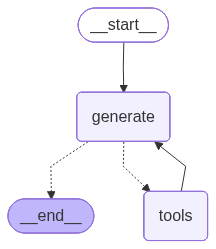

In [15]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [16]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 서울 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

gathered

현재 서울의 시각은 2026년 6월 29일 오후 9시 46분입니다.

AIMessageChunk(content='현재 서울의 시각은 2026년 6월 29일 오후 9시 46분입니다.', additional_kwargs={}, response_metadata={'model': 'qwen2.5:3bqwen2.5:3b', 'created_at': '2026-06-29T12:46:45.594565878Z2026-06-29T12:46:46.08601655Z', 'done': True, 'done_reason': 'stopstop', 'total_duration': 975129441, 'load_duration': 504571243, 'prompt_eval_count': 635, 'prompt_eval_duration': 73059000, 'eval_count': 54, 'eval_duration': 387522000, 'logprobs': None, 'model_name': 'qwen2.5:3bqwen2.5:3b', 'model_provider': 'ollama'}, id='lc_run--019f136a-f770-72c2-9f0d-98077655dbfa', tool_calls=[{'name': 'get_current_time', 'args': {'location': '서울'}, 'id': 'e885b0b3-04c3-4f48-b884-cc390497d183', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 635, 'output_tokens': 54, 'total_tokens': 689}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"location": "\\uc11c\\uc6b8"}', 'id': 'e885b0b3-04c3-4f48-b884-cc390497d183', 'index': None, 'type': 'tool_call_chunk'}], chunk_position='last')

In [ ]:
from langchain_core.messages import AIMessageChunk, SystemMessage

about = "북중미 월드컵 패배"

inputs = [SystemMessage(content=f"""
너는 스포츠 신문 기자이다. 
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.  

- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고 이유를 설명. 
- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해. 
- 검색할 리스트를 토대로 재검색을 해 
- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해.

더 이상 검색할 내용이 없다면, 동아일보 신문 기사 형식으로 최종 기사를 작성하라.
제목, 부제, 리드문, 본문 의 구성으로 작성해
본문 내용은 구체적이고 깊이 있게 작성해. 
    
""")]

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')



-------- WEB SEARCH --------
최근 북중미 월드컵 패배 비판 분석
w
1. snippet: 주먹으로 그라운드 '쾅쾅쾅'…32강 자력 진출 실패에 이강인 분노 24일 (현지시간) 멕시코 몬테레이 스타디움에서 2026 국제축구연맹 (FIFA) 북중미 월드컵 A조 조별리그 3차전 대한민국과 남아프리카공화국의 경기 종료 직후 이강인이 아쉬워하고 있다. 강정현 기자 한국 축구대표팀 미드필더 ..., title: 조별 전력분석 | 2026 북중미월드컵 | 중앙일보, link: https://www.joongang.co.kr/2026worldcup/teamanalysis
2. snippet: 대한민국 A조 조별리그 최종 성적표 한국은 이번 2026 북중미 월드컵 조별리그 A조에서 체코, 멕시코, 남아프리카 공화국과 경쟁을 펼쳤습니다. 1차전 체코를 상대로 기분 좋은 역전승을 거두며 32강 진출 확률을 94%까지 끌어올렸으나, 이후 내리 2연패를 당하며 조 3위로 주저앉았습니다. 2026 월드컵 A조 ..., title: 월드컵 한국 32강 진출 실패, 패인 분석, 향후 일정 총정리, link: https://www.lifedoit.co.kr/2026/06/32_01363717193.html
3. snippet: 대한민국 축구 국가대표팀이 2026 국제축구연맹 (FIFA) 북중미 월드컵 32강 진출 확정에 실패하자 '한국축구 레전드' 박지성 JTBC 해설위원도 홍명보 감독 등 축구 국가대표팀을 향해 거센 비판 목소리를 냈다., title: 박지성, 홍명보 전술 작심 비판 "이기려고 한 경기 맞나, 월드컵 ..., link: https://www.starnewskorea.com/sports/2026/06/25/2026062511124486358
4. snippet: JTBC 해설위원은 홍명보 감독을 향해 작심 비판을 쏟아냈다. 그러면서 12년 전 이영표가 홍명보와 3년이나 연락이 끊겼던 일까지 다시 소환됐다. 후배 둘이 같은 감독을 향해 같은 말을 반복